In [1]:
pip install umap-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.1
    Uninstalling scikit-learn-1.5.1:
      Successfully uninstalled scikit-learn-1.5.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

#umap-learn isnt part of sklearn so gotta install it separately

import umap

sns.set_style("whitegrid")

In [4]:
DATA_PATH = r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\TCGA-PANCAN-HiSeq-801x20531\data.csv"
LABELS_PATH = r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\TCGA-PANCAN-HiSeq-801x20531\labels.csv"

data_df = pd.read_csv(DATA_PATH, index_col=0)
labels_df = pd.read_csv(LABELS_PATH, index_col=0)

print("data shape:", data_df.shape)   # should be (801, 20531)
print("labels shape:", labels_df.shape)


print(data_df.head())
print(labels_df["Class"].value_counts())

data shape: (801, 20531)
labels shape: (801, 1)
          gene_0    gene_1    gene_2    gene_3     gene_4  gene_5    gene_6  \
sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0  7.175175   
sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0  6.816049   
sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0  6.972130   
sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0  7.843375   
sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0  6.566967   

            gene_7  gene_8  gene_9  ...  gene_20521  gene_20522  gene_20523  \
sample_0  0.591871     0.0     0.0  ...    4.926711    8.210257    9.723516   
sample_1  0.000000     0.0     0.0  ...    4.593372    7.323865    9.740931   
sample_2  0.452595     0.0     0.0  ...    5.125213    8.127123   10.908640   
sample_3  0.434882     0.0     0.0  ...    6.076566    8.792959   10.141520   
sample_4  0.360982     0.0     0.0  ...    5.996032    8.891425   10.373790   

  

In [5]:
#some genes probably barely change across samples (near-zero variance), these dont really help us so we can drop the worst offenders

gene_variances = data_df.var(axis=0)
#keep only genes that have SOME variance, cutoff is somewhat arbitrary

keep_cols = gene_variances[gene_variances > 0.0].index
data_df = data_df[keep_cols]
print("shape after dropping zero-variance genes:", data_df.shape)

#scaling everything - PCA is sensitive to scale so this step matters, StandardScaler makes each gene have mean 0 and std 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_df)

y = labels_df["Class"].values  #our cancer type labels (BRCA, LUAD etc)

shape after dropping zero-variance genes: (801, 20264)


running PCA...


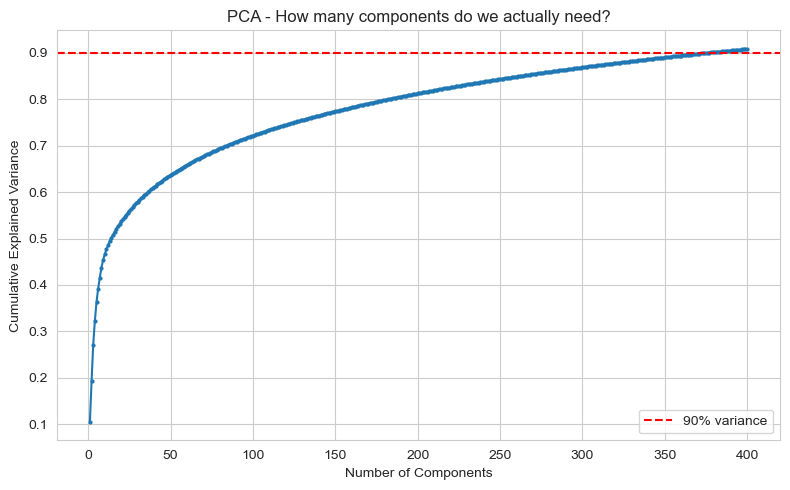

saved pca_explained_variance.png
need 376 components to explain 90% of variance


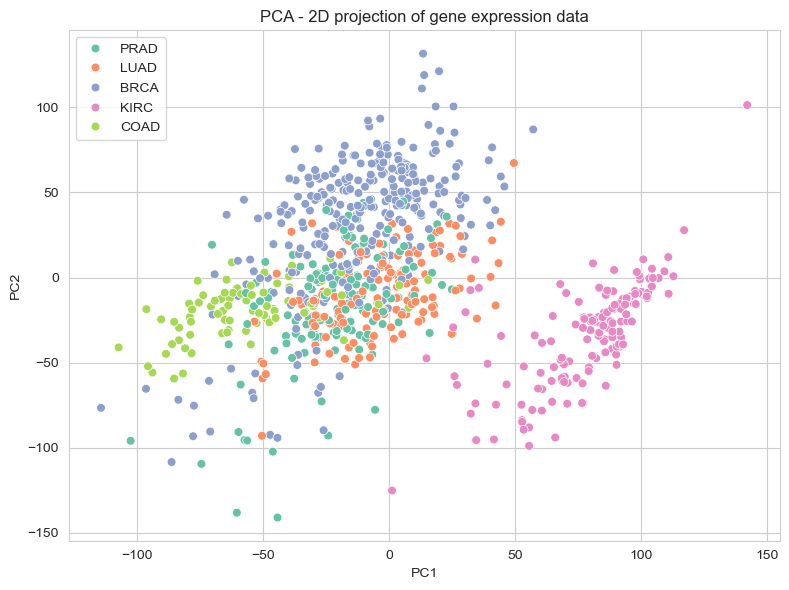

saved pca_2d_scatter.png


In [6]:
#fit PCA with a lot of components first just to look at the "explained variance" curve (this tells us how many components we actually need to keep most of the info)

print("running PCA...")
#originally I capped this at 100 components but turns out with data this messy/high-dim, you need WAY more than 100 to hit high variance, so bumping it up. (gene expression data has a LOT of spread out variance, not like a couple images where a handful of components does it)

N_COMPONENTS_TO_CHECK = 400
pca_full = PCA(n_components=N_COMPONENTS_TO_CHECK, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

#here im explaining cumulative variance - basically "how much information did we keep"
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, N_COMPONENTS_TO_CHECK + 1), cum_var, marker='o', markersize=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - How many components do we actually need?")
plt.legend()
plt.tight_layout()
plt.savefig("pca_explained_variance.png")
plt.show()
print("saved pca_explained_variance.png")

#find how many components we need to hit 90% variance

#safety check here. if we never actually hit 90% within the components we checked, argmax would just silently give us 0 which is wrong, so we check for that instead of trusting it blindly

if cum_var[-1] < 0.90:
    print(f"heads up: only reached {cum_var[-1]*100:.1f}% variance with "
          f"{N_COMPONENTS_TO_CHECK} components, need more than that for 90%")
    n_components_90 = N_COMPONENTS_TO_CHECK  # just use what we've got
else:
    n_components_90 = np.argmax(cum_var >= 0.90) + 1

print(f"need {n_components_90} components to explain 90% of variance")
#still WAY less than the original 20000+ genes, thats the whole point

#now lets just use 2 components so we can actually plot it and see clusters
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette="Set2", s=40)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D projection of gene expression data")
plt.tight_layout()
plt.savefig("pca_2d_scatter.png")
plt.show()
print("saved pca_2d_scatter.png")

running t-SNE (this can take a minute)...
t-SNE done in 2.1 seconds


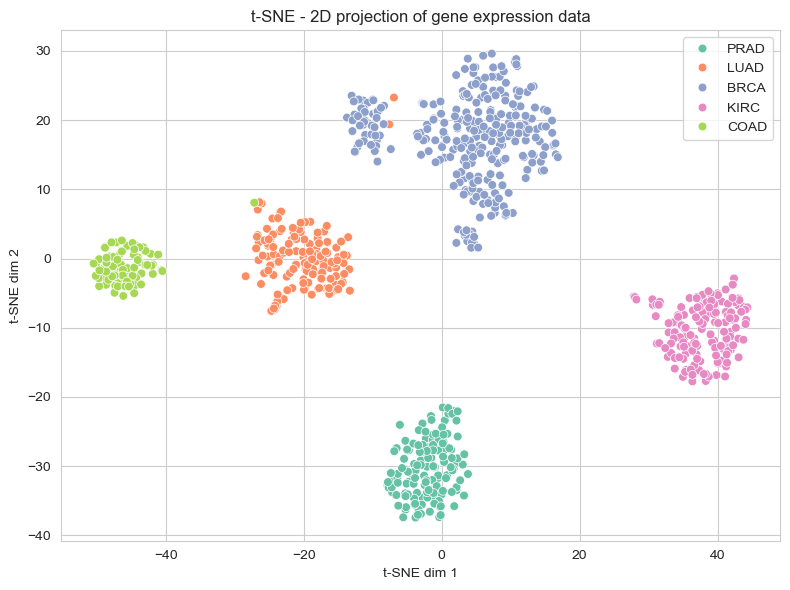

saved tsne_2d_scatter.png


In [7]:
#t-SNE is SLOW on high dimensional data so its common practice to run PCA first to knock it down to like 50 dims, then t-SNE on top of that. Doing t-SNE directly on 20000+ raw dims takes forever

print("running t-SNE (this can take a minute)...")
start = time.time()

pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_pca_50)

print(f"t-SNE done in {time.time() - start:.1f} seconds")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="Set2", s=40)
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.title("t-SNE - 2D projection of gene expression data")
plt.tight_layout()
plt.savefig("tsne_2d_scatter.png")
plt.show()
print("saved tsne_2d_scatter.png")

running my UMAP...


C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


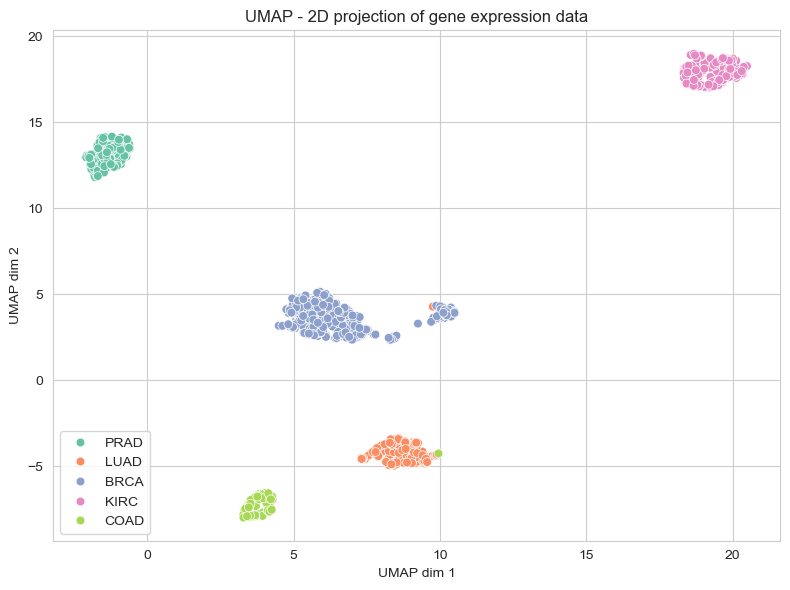

saved umap_2d_scatter.png


In [8]:
print("running my UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca_50)  # feeding it the PCA-50 version too

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="Set2", s=40)
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.title("UMAP - 2D projection of gene expression data")
plt.tight_layout()
plt.savefig("umap_2d_scatter.png")
plt.show()
print("saved umap_2d_scatter.png")

In [9]:
print("\n--- COMPARISON: raw features vs PCA reduced features ---")

#split same way for both so its a fair comparison
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

#Approach A: raw features (all genes) --
print("\ntraining on RAW features (all genes)...")
start = time.time()
rf_raw = RandomForestClassifier(n_estimators=200, random_state=42)
rf_raw.fit(X_train_raw, y_train)
raw_train_time = time.time() - start

y_pred_raw = rf_raw.predict(X_test_raw)
raw_acc = accuracy_score(y_test, y_pred_raw)

print(f"raw features -> accuracy: {raw_acc:.4f}, training time: {raw_train_time:.2f}s")

#Approach B: PCA reduced features. redo PCA using only the training set (dont want to leak test info into PCA)

print(f"\ntraining on PCA reduced features ({n_components_90} components)...")

pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_raw)
X_test_pca = pca_final.transform(X_test_raw)  # just transform, dont refit!

start = time.time()
rf_pca = RandomForestClassifier(n_estimators=200, random_state=42)
rf_pca.fit(X_train_pca, y_train)
pca_train_time = time.time() - start

y_pred_pca = rf_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)

print(f"PCA features -> accuracy: {pca_acc:.4f}, training time: {pca_train_time:.2f}s")


--- COMPARISON: raw features vs PCA reduced features ---

training on RAW features (all genes)...
raw features -> accuracy: 0.9851, training time: 3.33s

training on PCA reduced features (376 components)...
PCA features -> accuracy: 0.9154, training time: 1.11s


In [10]:
print("Summary :")
print(f"Raw features ({X_scaled.shape[1]} dims):")
print(f"  accuracy = {raw_acc:.4f}, time = {raw_train_time:.2f}s")
print(f"PCA features ({n_components_90} dims):")
print(f"  accuracy = {pca_acc:.4f}, time = {pca_train_time:.2f}s")
print(f"\nspeedup: {raw_train_time / pca_train_time:.1f}x faster with PCA")
print("dimensionality reduced by:", round(100 * (1 - n_components_90 / X_scaled.shape[1]), 2), "%")

print("\nfull classification report (PCA model):")
print(classification_report(y_test, y_pred_pca))

Summary :
Raw features (20264 dims):
  accuracy = 0.9851, time = 3.33s
PCA features (376 dims):
  accuracy = 0.9154, time = 1.11s

speedup: 3.0x faster with PCA
dimensionality reduced by: 98.14 %

full classification report (PCA model):
              precision    recall  f1-score   support

        BRCA       0.84      1.00      0.91        75
        COAD       1.00      0.85      0.92        20
        KIRC       1.00      0.95      0.97        37
        LUAD       0.96      0.69      0.80        35
        PRAD       0.94      0.97      0.96        34

    accuracy                           0.92       201
   macro avg       0.95      0.89      0.91       201
weighted avg       0.92      0.92      0.91       201

